<a href="https://colab.research.google.com/github/IrisCheon/NLP-practice/blob/main/Emotion_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Emotion Classification with TF-IDF, Logistic Regression, and LinearSVC

This notebook explores multi-class emotion classification using the `dair-ai/emotion` dataset.

The analysis compares TF-IDF based Logistic Regression and LinearSVC models across six emotion categories:
- sadness
- joy
- love
- anger
- fear
- surprise

In addition to overall performance metrics, the notebook focuses on:
- confusion patterns between emotions
- confidence analysis
- class-wise recall/precision tradeoffs
- feature importance and emotion-related wording
- qualitative error analysis

The goal is not only to evaluate classification accuracy, but also to examine how different models interpret ambiguous emotional language.

In [71]:
!pip install datasets

In [72]:
from datasets import load_dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

dataset = load_dataset("dair-ai/emotion")

In [73]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [74]:
dataset["train"][0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [75]:
dataset["train"].features

{'text': Value('string'),
 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}

In [76]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

# ■ 데이터 확인

In [77]:
train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [78]:
train_df["label"].value_counts()

,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


In [79]:
dataset["train"].features["label"]

ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])

In [80]:
label_names = dataset["train"].features["label"].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [81]:
train_df["emotion"] = train_df["label"].apply(lambda x: label_names[x])
val_df["emotion"] = val_df["label"].apply(lambda x: label_names[x])
test_df["emotion"] = test_df["label"].apply(lambda x: label_names[x])

In [82]:
train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


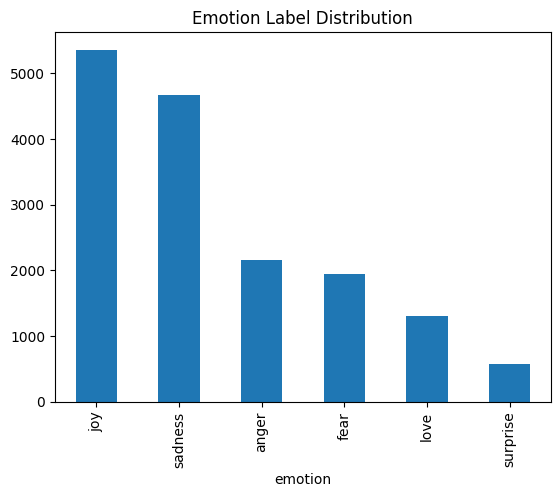

In [83]:
train_df["emotion"].value_counts().plot(kind="bar")
plt.title("Emotion Label Distribution")
plt.show()

In [84]:
train_df["text_length"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

In [85]:
train_df.groupby("emotion")[["text_length", "word_count"]].describe()
# word_count는 유의미하게 차이 없음
# text_length는 love, surprise가 긴 편(min, 25%에서도 높은것 보면 그냥 전반적으로 높은 듯)

text_length                                                          \
               count        mean        std   min   25%   50%     75%    max   
emotion                                                                        
anger         2159.0   96.911533  57.677478   9.0  51.0  85.0  132.00  298.0   
fear          1937.0   96.123903  55.187941   9.0  54.0  85.0  126.00  296.0   
joy           5362.0   98.554457  55.032087   9.0  56.0  89.0  130.00  300.0   
love          1304.0  104.033742  55.145913  13.0  62.0  94.0  137.00  299.0   
sadness       4666.0   92.550579  56.085306   7.0  49.0  80.0  122.75  299.0   
surprise       572.0  101.676573  57.245763  12.0  58.0  88.5  132.25  287.0   

         word_count                                                     
              count       mean        std  min   25%   50%   75%   max  
emotion                                                                 
anger        2159.0  19.229736  11.426926  2.0  10.0  17.0  26.0  62.0  
fear         1937.0  18.844605  10.890188  2.0  10.0  17.0  25.0  60.0  
joy          5362.0  19.498135  10.772118  2.0  11.0  18.0  26.0  64.0  
love         1304.0  20.700153  10.827956  3.0  12.0  19.0  27.0  63.0  
sadness      4666.0  18.361980  11.037223  2.0  10.0  16.0  24.0  66.0  
surprise      572.0  19.970280  11.031756  3.0  12.0  18.0  26.0  60.0

#■ ML

In [87]:
X_train = train_df["text"]
X_test = test_df["text"]

y_train = train_df["emotion"]
y_test = test_df["emotion"]

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [90]:
# Logistic Regression

lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features = 10000,
        ngram_range = (1,2),
        stop_words = "english"
    )),
    ("clf", LogisticRegression(
        max_iter = 1000
    ))
])

In [91]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

In [92]:
y_pred_lr = lr_model.predict(X_test)

In [93]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

       anger       0.92      0.83      0.87       275
        fear       0.90      0.86      0.88       224
         joy       0.86      0.96      0.91       695
        love       0.82      0.65      0.73       159
     sadness       0.92      0.94      0.93       581
    surprise       0.94      0.52      0.67        66

    accuracy                           0.89      2000
   macro avg       0.89      0.79      0.83      2000
weighted avg       0.89      0.89      0.88      2000



joy와 sadness 전반적으로 점수가 높음
- recall이 매우 높은데 precision은 86% > joy로 예측한 값이 많은 듯

love와 surprise는 잘 못 찾는 편.
- surprise는 recall이 낮음(절반은 다른걸로 예측했다)
- love는 전반적으로 못 잡음(recall도 precision도 모두 낮음)


In [94]:
from sklearn.metrics import confusion_matrix

In [95]:
labels = label_names
cm = confusion_matrix(y_test, y_pred_lr, labels = labels)
cm_df = pd.DataFrame(
    cm,
    index = [f"actual_{l}" for l in labels],
    columns = [f"pred_{l}" for l in labels]
)

cm_df

# surprise를 fear로 예측한 경우가 유난히 많음
# love도 1/3은 joy로 예측

,pred_sadness,pred_joy,pred_love,pred_anger,pred_fear,pred_surprise
actual_sadness,549,18,1,10,3,0
actual_joy,3,669,19,1,1,2
actual_love,9,45,103,2,0,0
actual_anger,19,21,1,229,5,0
actual_fear,15,9,1,7,192,0
actual_surprise,3,15,0,1,13,34


#■ 세부 데이터 확인

In [96]:
results = pd.DataFrame({
    "text" : X_test,
    "actual" : y_test,
    "predicted" : y_pred_lr
})

errors = results[results["actual"] != results["predicted"]]
errors.head()

,text,actual,predicted
9,i jest i feel grumpy tired and pre menstrual w...,anger,joy
10,i don t feel particularly agitated,fear,anger
12,i pay attention it deepens into a feeling of b...,fear,sadness
31,i posted on my facebook page earlier this week...,anger,sadness
40,i feel if i completely hated things i d exerci...,anger,sadness


In [97]:
errors.groupby(["actual", "predicted"]).size().reset_index(name="count").sort_values("count", ascending = False)

,actual,predicted,count
14,love,joy,45
1,anger,joy,21
10,joy,love,19
3,anger,sadness,19
18,sadness,joy,18
22,surprise,joy,15
7,fear,sadness,15
21,surprise,fear,13
16,sadness,anger,10
5,fear,joy,9


In [105]:
love_joy_error = errors[
    (errors["actual"] == "love") & (errors["predicted"] == "joy")
]

love_joy_error.head()

,text,actual,predicted
74,i were to go overseas or cross the border then...,love,joy
96,i love neglecting this blog but sometimes i fe...,love,joy
111,i feel is he generous,love,joy
131,im feeling generous today heres one more you m...,love,joy
149,i feel that i need to know that i can depend o...,love,joy


In [106]:
for text in love_joy_error["text"].head(10):
    print(text)
    print("-" * 50)

# love - joy는 특성상 구분자체가 쉽지 않아보임

i were to go overseas or cross the border then i become a foreigner and will feel that way but never in my beloved land
--------------------------------------------------
i love neglecting this blog but sometimes i feel for my faithful readers
--------------------------------------------------
i feel is he generous
--------------------------------------------------
im feeling generous today heres one more you may have already seen but is good for a chuckle
--------------------------------------------------
i feel that i need to know that i can depend on myself before i put myself in the position of supporting someone else and being supported by someone else
--------------------------------------------------
i feel so blessed and honored that we get to be its parents
--------------------------------------------------
i was so impressed with the show especially for hs and i was moved by these talented kids but then again i feel very passionate about productions and music and theatre in s

In [127]:
anger_joy_error = errors[
    (errors["actual"] == "anger") & (errors["predicted"] == "joy")
]

anger_joy_error.head()

,text,actual,predicted,confidence,correct
9,i jest i feel grumpy tired and pre menstrual w...,anger,joy,0.293039,False
411,i love that this is a place a series with no r...,anger,joy,0.280193,False
477,i know that you feel pretty disgusted by the n...,anger,joy,0.368651,False
501,when we rearranged furniture in our flat and g...,anger,joy,0.315188,False
518,i watched the news at the tv,anger,joy,0.403508,False


In [128]:
for text in anger_joy_error["text"].head(10):
    print(text)
    print("-" * 50)

i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on vacation for the summer
--------------------------------------------------
i love that this is a place a series with no real heroes and i love that the way the couples in these books fall in love feels just as violent and crazy as the place that they call home
--------------------------------------------------
i know that you feel pretty disgusted by the nonstop lefty propaganda the ministry churns out but of the public isn t that tuned in
--------------------------------------------------
when we rearranged furniture in our flat and got stuck in a chair
--------------------------------------------------
i watched the news at the tv
--------------------------------------------------
i was playing a sport in an advanced pe class and many of the people were not advanced
--------------------------------------------------
i feel like i should be listening 

세부 텍스트 확인

- i love that this is a place a series with no real heroes and i love that the way the couples in these books fall in love feels just as violent and crazy as the place that they call home
- i was playing a sport in an advanced pe class and many of the people were not advanced
- when we rearranged furniture in our flat and got stuck in a chair

위는 단어 자체가 부정적인 것은 크게 없어보임 > anger로 분류하기 어려웠을 수 있음


In [129]:
surprise_fear_error = errors[
    (errors["actual"] == "surprise") & (errors["predicted"] == "fear")
]

for text in surprise_fear_error["text"].head(10):
    print(text)
    print("-" * 50)

# "strange", "feel" 이 유난히 많이 등장하는 것이 보임. "weird"도 때때로.
# "strange" 와 "weird"는 surprise의 coef 상위임

i am right handed however i play billiards left handed naturally so me trying to play right handed feels weird
--------------------------------------------------
i was so uncomfortable and feeling weird feelings but wasn t sure if they were contractions since i never really felt contractions with jared until they jacked me up with pitocin
--------------------------------------------------
i feel thats just strange on wotcs behalf
--------------------------------------------------
i feel a strange gratitude for the hated israeli occupation of sinai that lasted from to for actually recognizing the importance of sinais history
--------------------------------------------------
i replied feeling strange at giving the orders
--------------------------------------------------
i feel shame in a strange way
--------------------------------------------------
i start to feel a little overwhelmed knowing i have to make still
--------------------------------------------------
i stay the more dista

In [100]:
proba = lr_model.predict_proba(X_test)
confidence = proba.max(axis=1)

results["confidence"] = confidence
results.sort_values("confidence", ascending=False).head(20)

,text,actual,predicted,confidence
1312,i find myself feeling anxious and unsure,fear,fear,0.996583
1975,i feel scared anxious,fear,fear,0.993200
1940,i feel so discontent so guilty so pathetic so ...,sadness,sadness,0.992362
1040,i feel intimidated nervous and overwhelmed and...,fear,fear,0.991951
1532,i feel useful and valued and that is fundament...,joy,joy,0.991132
610,i feel pissed off and angry,anger,anger,0.989229
296,i sometimes have urges to just freak out becau...,anger,anger,0.989019
387,i always feel so pressured,fear,fear,0.988359
1367,i feel pressured to do well and i fe,fear,fear,0.988359
478,i feel complacent and satisfied,joy,joy,0.987449


In [111]:
errors = results[results["actual"] != results["predicted"]]
errors.sort_values("confidence", ascending=False).head(20)

,text,actual,predicted,confidence,correct
131,im feeling generous today heres one more you m...,love,joy,0.805445,False
1943,i didn t mean to get angry with you bommie i j...,sadness,anger,0.761028,False
729,i couldnt feel more blessed at this time,joy,love,0.744834,False
1154,i feel that passionate about,joy,love,0.738771,False
193,i really dont like quinn because i feel like s...,anger,sadness,0.719916,False
229,i am truly unfortunate the majority of the tim...,fear,sadness,0.713466,False
303,i was so impressed with the show especially fo...,love,joy,0.704452,False
901,i feel so blessed to have friends i can come to,joy,love,0.703236,False
1842,i feel so amazing musicjuzz,joy,surprise,0.698187,False
1576,i cant do a simple math question and guess wha...,fear,sadness,0.697902,False


In [117]:
errors.sort_values("confidence").head(20)

,text,actual,predicted,confidence,correct
1832,i disagree with my parents on many issues and ...,anger,joy,0.246505,False
72,i am right handed however i play billiards lef...,surprise,fear,0.256299,False
1172,i started feeling uncomfortable around my stra...,fear,love,0.265226,False
1684,i feel this weekend is going to be a slutty one,love,sadness,0.266375,False
1162,i would always have this song stuck in my head...,fear,sadness,0.267400,False
468,i cant help feeling this way,sadness,joy,0.267739,False
762,i usually ignore page invites that are irrelev...,anger,joy,0.268416,False
1995,i just keep feeling like someone is being unki...,anger,sadness,0.269515,False
411,i love that this is a place a series with no r...,anger,joy,0.280193,False
922,i was lying in bed last night after a day of m...,anger,fear,0.285031,False


In [115]:
errors.groupby(["actual", "predicted"])["confidence"].mean()

# fear - sadness, joy - love, joy - surprise, sadness - anger, sadness - love
# 위에서 살펴본 anger-joy는 confidence가 0.38. love-joy는 50% 가량인것을 볼 때 대조적

actual    predicted
anger     fear         0.406684
          joy          0.384321
          love         0.328380
          sadness      0.461158
fear      anger        0.432727
          joy          0.365785
          love         0.265226
          sadness      0.519105
joy       anger        0.338314
          fear         0.408198
          love         0.530957
          sadness      0.451806
          surprise     0.569456
love      anger        0.482825
          joy          0.490346
          sadness      0.371828
sadness   anger        0.514929
          fear         0.458778
          joy          0.412512
          love         0.506781
surprise  anger        0.470828
          fear         0.444421
          joy          0.462371
          sadness      0.422950
Name: confidence, dtype: float64

# ■ coef

In [118]:
vectorizer = lr_model.named_steps["tfidf"]
clf = lr_model.named_steps["clf"]

feature_names = vectorizer.get_feature_names_out()

clf.classes_

array(['anger', 'fear', 'joy', 'love', 'sadness', 'surprise'],
      dtype=object)

In [119]:
# Sadness coef

class_idx = list(clf.classes_).index("sadness")

sadness_coef = clf.coef_[class_idx]

sadness_words = pd.DataFrame({
    "feature" : feature_names,
    "coef" : sadness_coef
}).sort_values("coef", ascending = False)

sadness_words.head(10)

,feature,coef
7166,punished,4.097918
6225,melancholy,4.050664
5308,lethargic,3.955226
9325,troubled,3.790460
9420,unfortunate,3.723971
1807,disturbed,3.716874
2158,exhausted,3.688205
6293,miserable,3.662418
8313,shitty,3.629626
6298,missed,3.626003


In [121]:
for emotion in clf.classes_:
    class_idx = list(clf.classes_).index(emotion)
    coef = clf.coef_[class_idx]

    words = pd.DataFrame({
        "feature": feature_names,
        "coef": coef
    }).sort_values("coef", ascending=False)

    print(emotion)
    display(words.head(10))

anger


,feature,coef
1526,dangerous,5.273932
3690,greedy,5.106706
771,bothered,5.045385
3456,fucked,5.005046
4514,irritable,4.981197
7895,rude,4.913644
1795,dissatisfied,4.838511
1802,distracted,4.774587
6574,offended,4.701686
648,bitchy,4.683958


fear


,feature,coef
8279,shaken,5.837270
8994,terrified,5.613127
7596,reluctant,5.249991
9564,vulnerable,5.038729
6700,paranoid,4.928539
276,apprehensive,4.879779
9396,uncertain,4.846662
7049,pressured,4.831551
4477,intimidated,4.830983
8282,shaky,4.746355


joy


...

,feature,coef
986,caring,6.094057
8890,sympathetic,5.656037
6078,loving,5.452726
8838,supportive,5.429408
6074,lovely,5.316584
5992,longing,5.312885
6413,naughty,5.249191
6521,nostalgic,5.224114
6083,loyal,5.204843
3373,fond,5.121361


sadness


,feature,coef
7166,punished,4.097918
6225,melancholy,4.050664
5308,lethargic,3.955226
9325,troubled,3.790460
9420,unfortunate,3.723971
1807,disturbed,3.716874
2158,exhausted,3.688205
6293,miserable,3.662418
8313,shitty,3.629626
6298,missed,3.626003


surprise


,feature,coef
4271,impressed,7.293827
192,amazed,7.205581
8860,surprised,6.721976
1489,curious,6.705385
8319,shocked,6.324767
3471,funny,6.077621
1569,dazed,5.288242
6653,overwhelmed,5.103347
9733,weird,4.948177
8707,strange,4.918678


# ■ LinearSVC

In [122]:
from sklearn.svm import LinearSVC

In [123]:
svc_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features = 10000,
        ngram_range = (1, 2),
        stop_words = "english"
    )),
    ("clf", LinearSVC())
])

In [124]:
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)

In [125]:
print(classification_report(y_test, y_pred_svc))

# 전반적으로 lr에 비해 recall이 개선됨(love, surprise)
#   다만, 위 둘의 precision은 떨어짐. 보다 공격적으로 탐지한 듯

              precision    recall  f1-score   support

       anger       0.91      0.91      0.91       275
        fear       0.88      0.86      0.87       224
         joy       0.92      0.94      0.93       695
        love       0.79      0.80      0.79       159
     sadness       0.95      0.94      0.94       581
    surprise       0.76      0.68      0.72        66

    accuracy                           0.91      2000
   macro avg       0.87      0.85      0.86      2000
weighted avg       0.90      0.91      0.90      2000



In [126]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

       anger       0.92      0.83      0.87       275
        fear       0.90      0.86      0.88       224
         joy       0.86      0.96      0.91       695
        love       0.82      0.65      0.73       159
     sadness       0.92      0.94      0.93       581
    surprise       0.94      0.52      0.67        66

    accuracy                           0.89      2000
   macro avg       0.89      0.79      0.83      2000
weighted avg       0.89      0.89      0.88      2000



In [130]:
labels = label_names
cm2 = confusion_matrix(y_test, y_pred_svc, labels = labels)
cm_df2 = pd.DataFrame(
    cm2,
    index = [f"actual_{l}" for l in labels],
    columns = [f"pred_{l}" for l in labels]
)

cm_df2
# joy와 sadness를 약간 덜 맞추고, love, anger, surprise를 잘 맞춤
# anger를 joy로 예측하는 경우도 줄었음
# love를 joy로 예측은 줄었지만, joy를 love로 예측은 늘었음

,pred_sadness,pred_joy,pred_love,pred_anger,pred_fear,pred_surprise
actual_sadness,547,13,2,15,4,0
actual_joy,4,650,31,2,3,5
actual_love,1,29,127,2,0,0
actual_anger,10,7,1,249,8,0
actual_fear,14,2,0,7,192,9
actual_surprise,2,8,0,0,11,45


In [132]:
# 비교용(LR)
cm_df

,pred_sadness,pred_joy,pred_love,pred_anger,pred_fear,pred_surprise
actual_sadness,549,18,1,10,3,0
actual_joy,3,669,19,1,1,2
actual_love,9,45,103,2,0,0
actual_anger,19,21,1,229,5,0
actual_fear,15,9,1,7,192,0
actual_surprise,3,15,0,1,13,34


In [136]:
# 전반적으로 LR이 SVC보다 joy로 예측하는 경우가 더 넓은 것 같음

pd.Series(y_pred_lr).value_counts()

,count
joy,777
sadness,598
anger,250
fear,214
love,125
surprise,36


In [137]:
pd.Series(y_pred_svc).value_counts()

,count
joy,709
sadness,578
anger,275
fear,218
love,161
surprise,59


In [138]:
y_test.value_counts()

,count
emotion,
joy,695
sadness,581
anger,275
fear,224
love,159
surprise,66


## ■ SVC coef

In [133]:
vectorizer2 = svc_model.named_steps["tfidf"]
clf2 = svc_model.named_steps["clf"]

feature_names2 = vectorizer2.get_feature_names_out()

clf2.classes_

array(['anger', 'fear', 'joy', 'love', 'sadness', 'surprise'],
      dtype=object)

In [134]:
for emotion in clf2.classes_:
    class_idx2 = list(clf2.classes_).index(emotion)
    coef2 = clf2.coef_[class_idx2]

    words = pd.DataFrame({
        "feature": feature_names2,
        "coef": coef2
    }).sort_values("coef", ascending=False)

    print(emotion)
    display(words.head(10))

anger


,feature,coef
1526,dangerous,4.377624
3690,greedy,4.015063
7895,rude,3.978673
3456,fucked,3.898016
1802,distracted,3.855879
648,bitchy,3.799124
771,bothered,3.786341
4514,irritable,3.770452
6849,petty,3.728935
1795,dissatisfied,3.723052


fear


,feature,coef
8279,shaken,4.510861
8994,terrified,4.293449
7596,reluctant,4.138643
7049,pressured,3.992443
276,apprehensive,3.950947
4477,intimidated,3.885964
9564,vulnerable,3.874261
6700,paranoid,3.836404
8282,shaky,3.819818
9396,uncertain,3.691505


joy


...

,feature,coef
8890,sympathetic,4.616358
6083,loyal,4.306580
8838,supportive,4.293325
986,caring,4.236519
3373,fond,4.219062
5992,longing,4.059561
8985,tender,3.901219
3514,gentle,3.891934
7860,romantic,3.861058
4012,horny,3.817411


sadness


,feature,coef
9420,unfortunate,3.878338
9325,troubled,3.650133
7166,punished,3.569390
6225,melancholy,3.509985
1807,disturbed,3.416813
5308,lethargic,3.413903
3564,gloomy,3.323156
1945,dull,3.257861
30,abused,3.214025
9454,unwelcome,3.204471


surprise


,feature,coef
192,amazed,4.908608
4271,impressed,4.771955
1489,curious,4.355064
8860,surprised,4.267022
8319,shocked,4.070842
1569,dazed,3.907487
3471,funny,3.419702
8770,stunned,3.337579
2077,enthralled,2.448371
193,amazing,2.032271


In [135]:
# 비교(LR)

for emotion in clf.classes_:
    class_idx = list(clf.classes_).index(emotion)
    coef = clf.coef_[class_idx]

    words = pd.DataFrame({
        "feature": feature_names,
        "coef": coef
    }).sort_values("coef", ascending=False)

    print(emotion)
    display(words.head(10))

anger


,feature,coef
1526,dangerous,5.273932
3690,greedy,5.106706
771,bothered,5.045385
3456,fucked,5.005046
4514,irritable,4.981197
7895,rude,4.913644
1795,dissatisfied,4.838511
1802,distracted,4.774587
6574,offended,4.701686
648,bitchy,4.683958


fear


,feature,coef
8279,shaken,5.837270
8994,terrified,5.613127
7596,reluctant,5.249991
9564,vulnerable,5.038729
6700,paranoid,4.928539
276,apprehensive,4.879779
9396,uncertain,4.846662
7049,pressured,4.831551
4477,intimidated,4.830983
8282,shaky,4.746355


joy


...

,feature,coef
986,caring,6.094057
8890,sympathetic,5.656037
6078,loving,5.452726
8838,supportive,5.429408
6074,lovely,5.316584
5992,longing,5.312885
6413,naughty,5.249191
6521,nostalgic,5.224114
6083,loyal,5.204843
3373,fond,5.121361


sadness


,feature,coef
7166,punished,4.097918
6225,melancholy,4.050664
5308,lethargic,3.955226
9325,troubled,3.790460
9420,unfortunate,3.723971
1807,disturbed,3.716874
2158,exhausted,3.688205
6293,miserable,3.662418
8313,shitty,3.629626
6298,missed,3.626003


surprise


,feature,coef
4271,impressed,7.293827
192,amazed,7.205581
8860,surprised,6.721976
1489,curious,6.705385
8319,shocked,6.324767
3471,funny,6.077621
1569,dazed,5.288242
6653,overwhelmed,5.103347
9733,weird,4.948177
8707,strange,4.918678


## Conclusion

The analysis showed that emotion classification involves substantial ambiguity between related emotions such as `joy` and `love`, as well as context-dependent confusion such as `anger` and `joy` in sarcastic expressions.

Comparing Logistic Regression and LinearSVC revealed different prediction tendencies. Logistic Regression predicted `joy` more frequently overall, while LinearSVC improved recall for `love`, `anger`, and `surprise` by separating emotional classes more aggressively.

The results suggest that emotion classification depends not only on keywords, but also on contextual and semantic interpretation of emotional language.